# Principal Component Analysis

Considere o conjunto de dados disponível em penguins.csv, organizado em 5 colunas, sendo 4 colunas de atributos e a última a classe do padrão. Os dados referem-se a medições anatômicas de pinguins da Antártida, classificados nas espécies Adelie, Chinstrap e Gentoo. Maiores detalhes sobre os dados podem ser achados em https://allisonhorst.github.io/palmerpenguins/.

Vamos aplicar a projeção dos dados em duas dimensões utilizando PCA (Principal Component Analysis)

In [ ]:
import torch
import pandas as pd
import os
from pathlib import Path
import sys
import numpy as np
from matplotlib import pyplot as plt


root = Path().resolve().parent  # aponta para machine-learning/
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from classes.pca import PCA

print(torch.cuda.is_available())
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

True
Using GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
data = torch.from_numpy(pd.read_csv(os.path.join(root, "data", "penguins.csv"), header=None).to_numpy())

In [3]:
X = data[:, :-1].float()  # Features
y = data[:, -1]  # Target

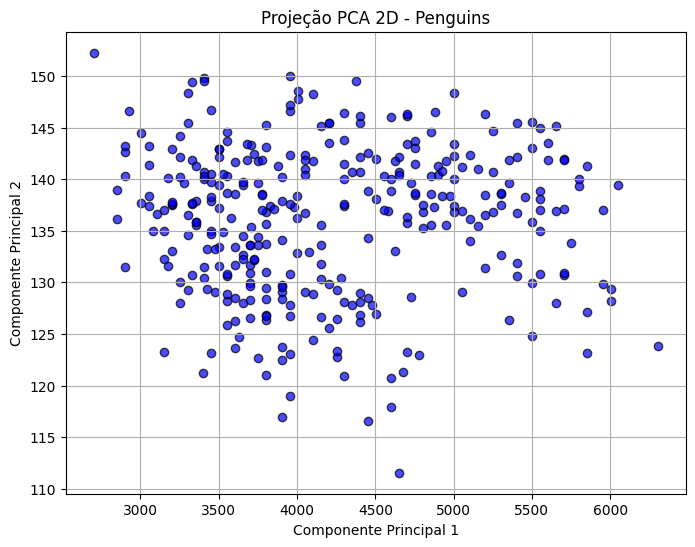

In [4]:
pca_custom = PCA(n_components=2)
pca_custom.fit(X)
X_projected = pca_custom.transform(X).numpy()

# Plotagem
plt.figure(figsize=(8, 6))
plt.scatter(X_projected[:, 0], X_projected[:, 1], alpha=0.7, c='blue', edgecolors='k')
plt.title("Projeção PCA 2D - Penguins")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.show()

Ainda considerando o item anterior, vamos mostrar a variância explicada obtida quando a dimensão projetada é modificada (1,2,3 ou 4). Lembrando que, se $\lambda_i$ é um autovalor de $S$ (Covariância dos dados) de forma que $\lambda_i \le \lambda_j$ para $i \le j$. Então a variância explicada da projeção em $D$ dimensões é dada por:
$$
    \text{Variância Explicada} = \frac{\sum_{i=1}^D \lambda_i}{\sum_{j=1}^M \lambda_j}
$$

In [7]:
dimensions = [1, 2, 3, 4]

variances = []
for dim in dimensions:
    pca_custom = PCA(n_components=dim)
    pca_custom.fit(X)
    variances.append(pca_custom.explained_variance.numpy())

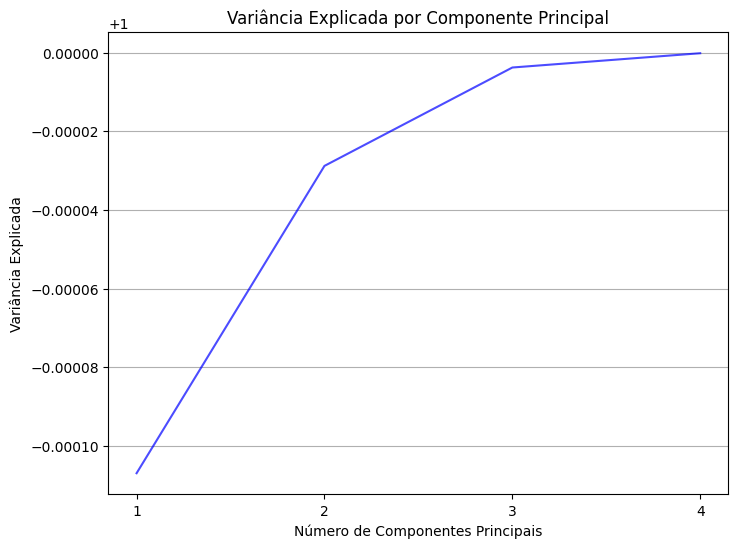

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(dimensions, variances, color='blue', alpha=0.7)
plt.title("Variância Explicada por Componente Principal")
plt.xlabel("Número de Componentes Principais")
plt.ylabel("Variância Explicada")
plt.xticks(dimensions)
plt.grid(axis='y')
plt.show()